# Practice 3: Customer Clustering - Bước 6.3: Hierarchical Clustering (Agglomerative)

---

## 1. Import các thư viện và tải dữ liệu đặc trưng đầy đủ

Chúng ta tải dữ liệu đã tiền xử lý từ `../data/processed_features/`.

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram
import time
import pickle
import os

%matplotlib inline

# Load dữ liệu 22 chiều đã xử lý đặc trưng
X_train = pd.read_csv('../data/processed_features/X_train.csv').values
X_val = pd.read_csv('../data/processed_features/X_val.values' if os.path.exists('../data/processed_features/X_val.values') else '../data/processed_features/X_val.csv').values

print(f'Kích thước dữ liệu huấn luyện: {X_train.shape}')
print(f'Kích thước dữ liệu xác thực:  {X_val.shape}')

Kích thước dữ liệu huấn luyện: (6455, 26)
Kích thước dữ liệu xác thực:  (1613, 26)


## 2. Hàm tính điểm Silhouette Score và Giảm chiều PCA từ Scratch

Để đánh giá chất lượng phân cụm và vẽ ranh giới cụm trong không gian 2D.

In [29]:
def custom_silhouette_score(X, labels):
    n_samples = X.shape[0]
    unique_labels = np.unique(labels)
    unique_labels = unique_labels[unique_labels != -1]
    n_clusters = len(unique_labels)
    
    if n_clusters <= 1 or n_clusters >= n_samples:
        return 0.0
        
    sum_squares = np.sum(X**2, axis=1, keepdims=True)
    dist_matrix = np.sqrt(np.maximum(sum_squares + sum_squares.T - 2 * np.dot(X, X.T), 0.0))
    
    s = np.zeros(n_samples)
    for i in range(n_samples):
        c_i = labels[i]
        if c_i == -1:
            continue
            
        same_cluster_idx = np.where(labels == c_i)[0]
        same_cluster_idx = same_cluster_idx[same_cluster_idx != i]
        if len(same_cluster_idx) > 0:
            a_i = np.mean(dist_matrix[i, same_cluster_idx])
        else:
            a_i = 0.0
            
        b_i = np.inf
        for c_j in unique_labels:
            if c_j == c_i:
                continue
            other_cluster_idx = np.where(labels == c_j)[0]
            mean_dist = np.mean(dist_matrix[i, other_cluster_idx])
            if mean_dist < b_i:
                b_i = mean_dist
                
        if max(a_i, b_i) > 0:
            s[i] = (b_i - a_i) / max(a_i, b_i)
        else:
            s[i] = 0.0
            
    valid_points = labels != -1
    return np.mean(s[valid_points])

class CustomPCA:
    def __init__(self, n_components=2):
        self.n_components = n_components
        self.components_ = None
        self.mean_ = None
        
    def fit(self, X):
        X_arr = np.array(X, dtype=float)
        self.mean_ = np.mean(X_arr, axis=0)
        X_centered = X_arr - self.mean_
        cov_matrix = np.cov(X_centered, rowvar=False)
        eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)
        sorted_indices = np.argsort(eigenvalues)[::-1]
        self.components_ = eigenvectors[:, sorted_indices][:, :self.n_components]
        return self
        
    def transform(self, X):
        X_arr = np.array(X, dtype=float)
        return np.dot(X_arr - self.mean_, self.components_)
        
    def fit_transform(self, X):
        self.fit(X)
        return self.transform(X)

pca_2d = CustomPCA(n_components=2)
X_train_2d = pca_2d.fit_transform(X_train)

## 3. Lập trình Hierarchical (Agglomerative) bằng Lance-Williams từ Scratch

Chúng ta lập trình cả 5 linkages (`single`, `complete`, `average`, `centroid`, `ward`) dựa trên công thức Lance-Williams cập nhật đệ quy ma trận khoảng cách hiệu năng cao.

In [30]:
class AgglomerativeClusteringScratch:
    def __init__(self, n_clusters=4, linkage='average'):
        self.n_clusters = n_clusters
        self.linkage = linkage
        self.labels_ = None
        self.linkage_matrix = None
        
    def fit_predict(self, X):
        n_samples = X.shape[0]
        sizes = {i: 1 for i in range(n_samples)}
        Z = []
        
        sum_squares = np.sum(X**2, axis=1, keepdims=True)
        dist_matrix = np.sqrt(np.maximum(sum_squares + sum_squares.T - 2 * np.dot(X, X.T), 0.0))
        
        dists = {i: {j: dist_matrix[i, j] for j in range(n_samples) if i != j} for i in range(n_samples)}
        active_clusters = list(range(n_samples))
        cluster_id_counter = n_samples
        
        steps = n_samples - 1
        for step in range(steps):
            min_d = np.inf
            u, v = -1, -1
            
            for i in range(len(active_clusters)):
                c_i = active_clusters[i]
                for j in range(i + 1, len(active_clusters)):
                    c_j = active_clusters[j]
                    d = dists[c_i][c_j]
                    if d < min_d:
                        min_d = d
                        u, v = c_i, c_j
                        
            if u == -1:
                break
                
            new_key = cluster_id_counter
            cluster_id_counter += 1
            
            Z.append([float(u), float(v), float(min_d), float(sizes[u] + sizes[v])])
            sizes[new_key] = sizes[u] + sizes[v]
            
            dists[new_key] = {}
            for w in active_clusters:
                if w == u or w == v:
                    continue
                
                d_uw = dists[u][w]
                d_vw = dists[v][w]
                d_uv = dists[u][v]
                
                n_u, n_v, n_w = sizes[u], sizes[v], sizes[w]
                
                if self.linkage == 'single':
                    d_new = min(d_uw, d_vw)
                elif self.linkage == 'complete':
                    d_new = max(d_uw, d_vw)
                elif self.linkage == 'average':
                    d_new = (n_u * d_uw + n_v * d_vw) / (n_u + n_v)
                elif self.linkage == 'centroid':
                    d_new_sq = (n_u / (n_u + n_v)) * (d_uw**2) + (n_v / (n_u + n_v)) * (d_vw**2) - (n_u * n_v / (n_u + n_v)**2) * (d_uv**2)
                    d_new = np.sqrt(max(d_new_sq, 0.0))
                elif self.linkage == 'ward':
                    n_sum = n_u + n_v + n_w
                    d_new_sq = ((n_u + n_w) / n_sum) * (d_uw**2) + ((n_v + n_w) / n_sum) * (d_vw**2) - (n_w / n_sum) * (d_uv**2)
                    d_new = np.sqrt(max(d_new_sq, 0.0))
                    
                dists[new_key][w] = d_new
                dists[w][new_key] = d_new
                
            active_clusters.remove(u)
            active_clusters.remove(v)
            del dists[u]
            del dists[v]
            for w in active_clusters:
                dists[w].pop(u, None)
                dists[w].pop(v, None)
                
            active_clusters.append(new_key)
            
        self.linkage_matrix = np.array(Z)
        self.labels_ = self._assign_labels_from_z(n_samples)
        return self.labels_
        
    def _assign_labels_from_z(self, n_samples):
        parent = {i: i for i in range(2 * n_samples)}
        n_merges = n_samples - self.n_clusters
        for i in range(n_merges):
            u, v, _, _ = self.linkage_matrix[i]
            u, v = int(u), int(v)
            new_key = n_samples + i
            parent[u] = new_key
            parent[v] = new_key
            
        roots = []
        for i in range(n_samples):
            curr = i
            while parent[curr] != curr:
                curr = parent[curr]
            roots.append(curr)
            
        unique_roots = sorted(list(set(roots)))
        root_to_label = {r: l for l, r in enumerate(unique_roots)}
        return np.array([root_to_label[r] for r in roots])

## 4. Kiểm chứng chéo và vẽ Dendrogram cho cả 5 Linkages

Linkage: single   | Silhouette Score: -0.0504
Linkage: complete | Silhouette Score: 0.1211
Linkage: average  | Silhouette Score: 0.1514
Linkage: centroid | Silhouette Score: -0.0383
Linkage: ward     | Silhouette Score: 0.1613


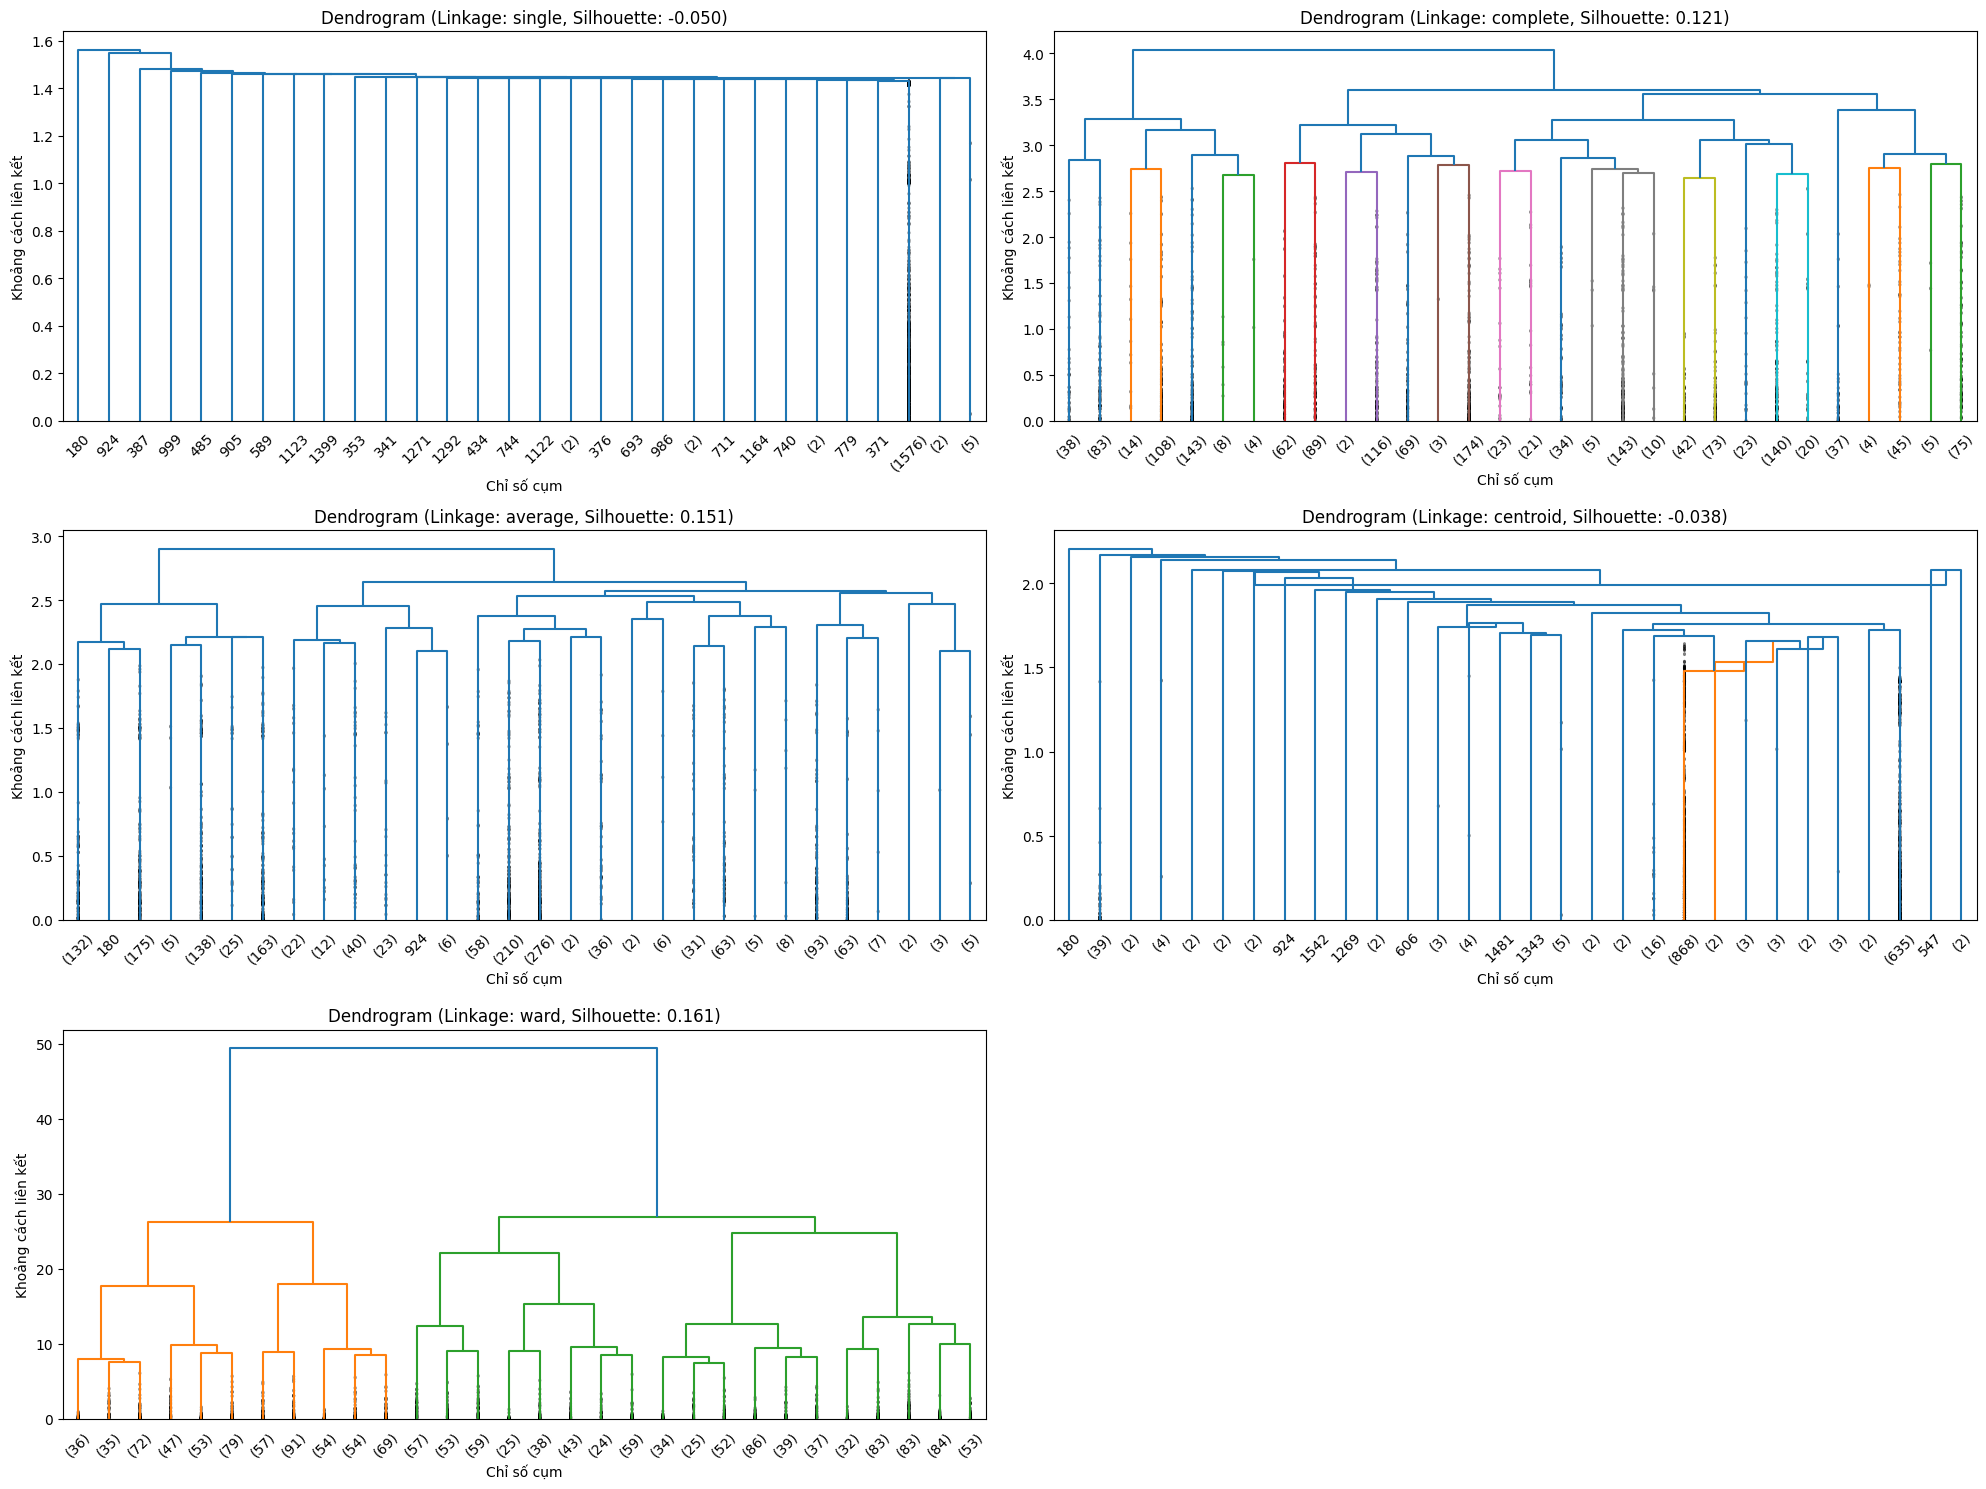

In [31]:
linkages = ['single', 'complete', 'average', 'centroid', 'ward']
plt.figure(figsize=(20, 15))

for idx, link in enumerate(linkages):
    hc = AgglomerativeClusteringScratch(n_clusters=4, linkage=link)
    labels = hc.fit_predict(X_val)
    score = custom_silhouette_score(X_val, labels)
    print(f'Linkage: {link:8s} | Silhouette Score: {score:.4f}')
    
    plt.subplot(3, 2, idx + 1)
    dendrogram(hc.linkage_matrix, truncate_mode='lastp', p=30, leaf_rotation=45, show_contracted=True)
    plt.title(f'Dendrogram (Linkage: {link}, Silhouette: {score:.3f})')
    plt.xlabel('Chỉ số cụm')
    plt.ylabel('Khoảng cách liên kết')

plt.tight_layout()
plt.show()

### 4.1. Phóng to Dendrogram Ward và xác định K=4 bằng đường cắt ngưỡng

Chúng ta vẽ phóng to riêng biểu đồ cây Dendrogram của thuật toán Ward tối ưu và kẻ thêm đường nằm ngang màu đỏ nét đứt tại cao độ `y = 25.5` để biểu diễn trực quan quá trình cắt cây thành đúng K = 4 cụm.

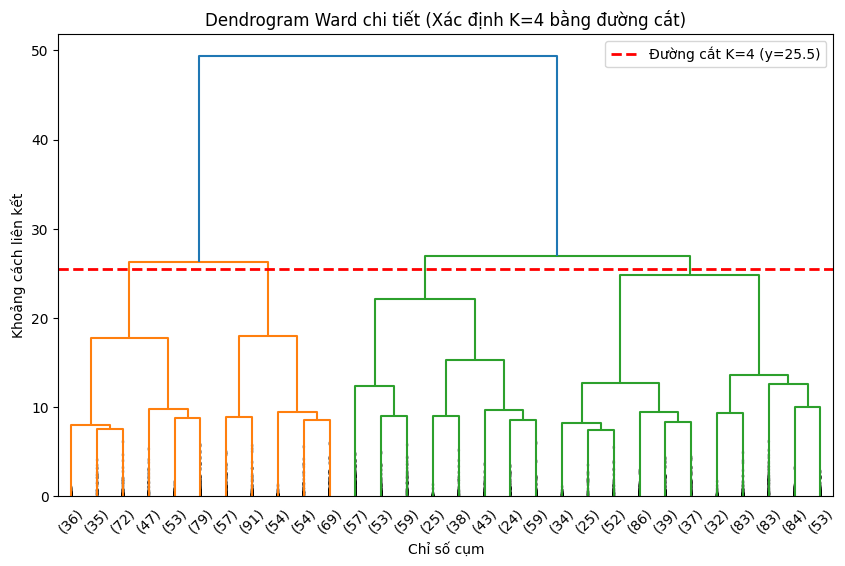

In [32]:
# Chạy riêng Ward linkage trên X_val
hc_ward = AgglomerativeClusteringScratch(n_clusters=4, linkage='ward')
labels_val_ward = hc_ward.fit_predict(X_val)

plt.figure(figsize=(10, 6))
dendrogram(hc_ward.linkage_matrix, truncate_mode='lastp', p=30, leaf_rotation=45, show_contracted=True)
plt.axhline(y=25.5, color='r', linestyle='--', linewidth=2, label='Đường cắt K=4 (y=25.5)')
plt.title('Dendrogram Ward chi tiết (Xác định K=4 bằng đường cắt)')
plt.xlabel('Chỉ số cụm')
plt.ylabel('Khoảng cách liên kết')
plt.legend()
plt.show()

## 5. Huấn luyện Hierarchical (Ward Linkage, K=4) & Trực quan hóa 2D

Do Hierarchical có độ phức tạp lưu trữ ma trận lớn, ta lấy ngẫu nhiên 2000 mẫu tập Train để chạy huấn luyện nhanh.

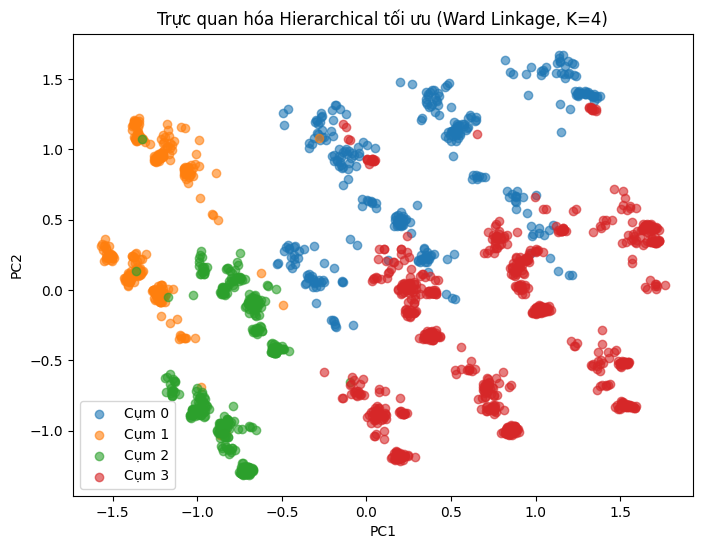

In [33]:
np.random.seed(42)
sub_train_idx = np.random.choice(X_train.shape[0], 2000, replace=False)
X_train_sub = X_train[sub_train_idx]
X_train_sub_2d = X_train_2d[sub_train_idx]

best_hierarchical = AgglomerativeClusteringScratch(n_clusters=4, linkage='ward')
train_labels_hier = best_hierarchical.fit_predict(X_train_sub)

plt.figure(figsize=(8, 6))
for k in range(4):
    idx = np.where(train_labels_hier == k)[0]
    plt.scatter(X_train_sub_2d[idx, 0], X_train_sub_2d[idx, 1], label=f'Cụm {k}', alpha=0.6)
plt.title('Trực quan hóa Hierarchical tối ưu (Ward Linkage, K=4)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.show()

## 6. Lưu trữ mô hình

In [34]:
with open('../models/hierarchical_linkage_matrix.pkl', 'wb') as f:
    pickle.dump(best_hierarchical.linkage_matrix, f)
with open('../models/hierarchical_scratch_labels.pkl', 'wb') as f:
    pickle.dump(train_labels_hier, f)
print('Đã lưu trữ ma trận liên kết Hierarchical thành công!')

Đã lưu trữ ma trận liên kết Hierarchical thành công!
